# Constrained Exploitation

This section demonstrates the implementation of constrained Bayesian optimization (BO) with exploitation as the acqusition function and a surrogate model for the constraint function is used to impose the constraint. The auxilliary optimization problem can be written as

$$
\begin{align*}
    \min_{x \in \Omega} \quad & \hat{f}(x) \\ 
    \text{subject to} \quad & \hat{g}_j(x) \leq 0, \quad j = 1, \dots, m\\
    & \hat{h}_k(x) = 0, \quad k = 1, \dots, n
\end{align*}
$$

where $\hat{f}(x)$ is the surrogate model prediction, $\hat{g}_j(x)$ is the surrogate model for the $j^{th}$ inequality constraint,  $\hat{h}_k(x)$ is the surrogate model for the $k^{th}$ equality constraint, $m$ is the number of inequality constraints and $n$ is the number of equality constraints. In the example of the constrained Branin function, there is only one inequality constraint and no equality constraints. The constrained exploitation method selects the next infill point in the process by minimizing the prediction of the surrogate model of the objective function subject to the prediction of the surrogate models of the constraints of the problem. As mentioned in the previous section, this method may lead to accelerated convergence to a local optimum since it does not perform any exploration. 

Below code imports required packages, defines modified branin function and constraint function:

In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pyDOE3 import lhs
from scimlstudio.models import SingleOutputGP
from scimlstudio.utils import Standardize, Normalize
from gpytorch.mlls import ExactMarginalLogLikelihood

from pymoo.core.problem import Problem
from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.optimize import minimize
from pymoo.config import Config
Config.warnings['not_compiled'] = False

# Defining the device and data types
args = {
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    "dtype": torch.float64
}

def modified_branin(x: np.ndarray) -> np.ndarray:
    """
        Function for computing modified branin function value at given input points
    """

    x = np.atleast_2d(x)

    x1 = x[:,0]
    x2 = x[:,1]

    a = 1.
    b = 5.1 / (4.*np.pi**2)
    c = 5. / np.pi
    r = 6.
    s = 10.
    t = 1. / (8.*np.pi)

    y = a * (x2 - b*x1**2 + c*x1 - r)**2 + s*(1-t)*np.cos(x1) + s + 5*x1

    return np.expand_dims(y,-1)

def constraint(x):
    """
        Function for computing constraint function value at given input points
    """

    x = np.atleast_2d(x)

    x1 = x[:,0]
    x2 = x[:,1]

    g = -x1*x2 + 30
    
    return np.expand_dims(g,-1)

# Bounds
lb = np.array([-5, 0])
ub = np.array([10, 15])

The block of code below defines the pymoo class for the auxiliary optimization of the constrained exploitation method. This class is essentially identical to the class that was implemented and described in detail within the previous section of BO. The only differences between the two classes is that to perform constrained optimization with pymoo it is necessary to specify the number of constraints while calling the `super().__init__` using the `n_constr` argument. Additionally, the `out` dictionary in the `_evaluate` method of the class must also store the constraint values through `out["G"]`. 

After the class is defined, the `differential evolution` class is initialized. The initialization of this class is identical to the one given in the previous section of BO. More details about the class can be found in the previous section. 

In [7]:
class ConstrainedExploitation(Problem):

    def __init__(self, gp_obj, gp_const,lb: np.ndarray, ub: np.ndarray):
        """
            Class for defining auxiliary optimization problem that uses
            exploitation as the acquisition function and imposes constraints directly.
            The constraint is imposed using the surrogate model of the constraint function. 
        """

        # initialize parent class
        super().__init__(n_var=lb.shape[0], n_obj=1, n_constr=1, xl=lb, xu=ub)

        self.gp_obj = gp_obj # store the surrogate model for the objective function
        self.gp_const = gp_const # store the surrogate model for the constraint function

    def _evaluate(self, x, out, *args, **kwargs):

        # convert to torch tensor
        x = torch.from_numpy(x).to(self.gp_obj.x_train)

        # get objective function prediction
        y_mean, _ = self.gp_obj.predict(x)

        # store the objective value as numpy array
        out["F"] = y_mean.numpy(force=True)

        # get constraint prediction
        g_mean, _ = self.gp_const.predict(x)

        # store the constraint value as numpy array
        out["G"] = g_mean.numpy(force=True)

# optimization algorithm
algorithm = DE(pop_size=15*lb.shape[0], F=0.9, CR=0.8, seed=1)

## BO Loop

The block of code below implements the BO loop for constrained exploitation. The number of initial samples is 4 with the maximum function evaluations set to 30. This means that there will be 26 iterations of the loop. Latin Hypercube sampling is used to generate the initial samples. Gaussian process (GP) models are used to approximate the modified Branin function and the constraint function of the problem. 
The mean prediction of the GP models are used for the objective and constraint functions in the auxiliary optimization problem. 

In [8]:
# variables
num_init = 4
max_evals = 30
num_evals = 0

# initial training data
x_train = lhs(lb.shape[0], samples=num_init, criterion='cm', iterations=100, seed=1)
x_train = lb + (ub - lb) * x_train
y_train = modified_branin(x_train)
g_train = constraint(x_train)

# increment evals
num_evals += num_init

ybest = np.min(y_train[g_train < 0])
idx_best = np.where(y_train == ybest)[0][0]
fbest = [ybest]
xbest = [x_train[idx_best]]
gbest = [g_train[idx_best]]

print("Current best before loop:")
print("x: {}".format(xbest[-1]))
print("f: {}".format(fbest[-1]))
print("g: {}".format(gbest[-1]))

print("\nConstrained Exploitation Loop:")

# loop
while num_evals < max_evals:

    print(f"\nIteration: {num_evals-num_init+1}")

    # training the objective function GP model
    gp_obj = SingleOutputGP(
        x_train=torch.from_numpy(x_train).to(**args),
        y_train=torch.from_numpy(y_train).to(**args),
        output_transform=Standardize,
        input_transform=Normalize,
    )
    mll_obj = ExactMarginalLogLikelihood(gp_obj.likelihood, gp_obj) # marginal log likelihood
    optimizer = torch.optim.Adam(gp_obj.parameters(), lr=0.01) # optimizer
    gp_obj.fit(training_iterations=1000, mll=mll_obj, optimizer=optimizer)

    # training the constraint function GP model
    gp_const = SingleOutputGP(
        x_train=torch.from_numpy(x_train).to(**args),
        y_train=torch.from_numpy(g_train).to(**args),
        output_transform=Standardize,
        input_transform=Normalize,
    )
    mll_const = ExactMarginalLogLikelihood(gp_const.likelihood, gp_const) # marginal log likelihood
    optimizer = torch.optim.Adam(gp_const.parameters(), lr=0.01) # optimizer
    gp_const.fit(training_iterations=1000, mll=mll_const, optimizer=optimizer)

    # find the minimum of surrogate model
    result = minimize(ConstrainedExploitation(gp_obj, gp_const, lb, ub), algorithm, verbose=False)

    # computing true function value at infill point
    y_infill = modified_branin(result.X)

    # computing true constraint value at infill point
    g_infill = constraint(result.X)

    print("New point (curret opt found using surroage models):")
    print("x: {}".format(result.X))
    print("f: {}".format(y_infill.item()))
    print("g: {}".format(g_infill.item()))

    # appending the the new point to the current data set
    x_train = np.vstack(( x_train, result.X.reshape(1,-1) ))
    y_train = np.vstack((y_train, y_infill))
    g_train = np.vstack((g_train, g_infill))

    # increment evals
    num_evals += 1

    # find current best point
    ybest = np.min(y_train[g_train < 0])
    idx_best = np.where(y_train == ybest)[0][0]
    fbest.append(ybest)
    xbest.append(x_train[idx_best])
    gbest.append(g_train[idx_best])
    
    print("Current best:")
    print("x: {}".format(xbest[-1]))
    print("f: {}".format(fbest[-1]))
    print("g: {}".format(gbest[-1]))

fbest = np.array(fbest)
xbest = np.array(xbest)
gbest = np.array(gbest)

Current best before loop:
x: [8.125 9.375]
f: 108.5539005871506
g: [-46.171875]

Constrained Exploitation Loop:

Iteration: 1
New point (curret opt found using surroage models):
x: [7.26806289 4.60177104]
f: 62.83973897546264
g: -3.445961336492445
Current best:
x: [7.26806289 4.60177104]
f: 62.83973897546264
g: [-3.44596134]

Iteration: 2
New point (curret opt found using surroage models):
x: [6.67860849 4.47191125]
f: 63.40395282151893
g: 0.13385561026910153
Current best:
x: [7.26806289 4.60177104]
f: 62.83973897546264
g: [-3.44596134]

Iteration: 3
New point (curret opt found using surroage models):
x: [4.79835021 6.03586238]
f: 56.89024712969006
g: 1.0378184729987936
Current best:
x: [7.26806289 4.60177104]
f: 62.83973897546264
g: [-3.44596134]

Iteration: 4
New point (curret opt found using surroage models):
x: [10.          3.21289172]
f: 51.98721341257178
g: -2.128917158633122
Current best:
x: [10.          3.21289172]
f: 51.98721341257178
g: [-2.12891716]

Iteration: 5
New point

Below block of code plots the evolution of the best objective function, best design point and constraint values of the constrained exploitation process.

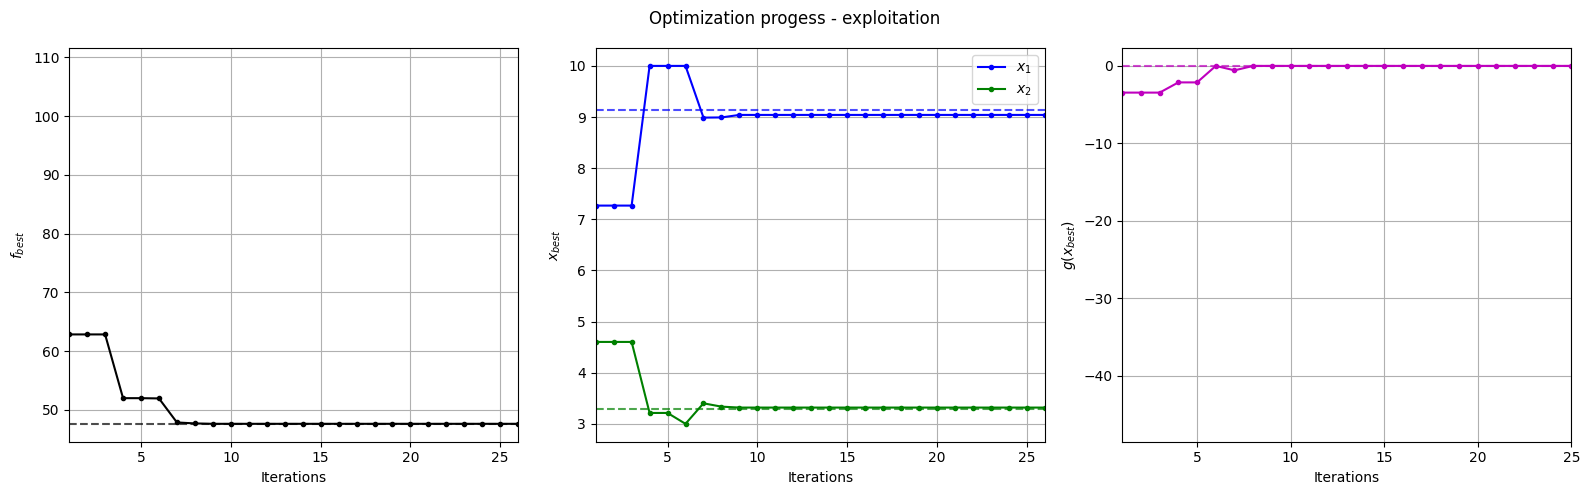

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].plot(fbest, ".k-")
ax[0].set_xlabel("Iterations")
ax[0].set_ylabel("$f_{best}$")
ax[0].axhline(y=modified_branin(np.array([[9.143, 3.281]])), c="k", linestyle="--", alpha=0.7)
ax[0].set_xlim(left=1, right=fbest.shape[0]-1)
ax[0].grid()

ax[1].plot(xbest[:,0], ".b-", label="$x_1$")
ax[1].plot(xbest[:,1], ".g-", label="$x_2$")
ax[1].axhline(y=9.143, c="b", linestyle="--", alpha=0.7)
ax[1].axhline(y=3.281, c="g", linestyle="--", alpha=0.7)
ax[1].set_xlim(left=1, right=xbest.shape[0]-1)
ax[1].set_ylabel("$x_{best}$")
ax[1].set_xlabel("Iterations")
ax[1].legend()
ax[1].grid()

ax[2].plot(gbest, ".m-")
ax[2].set_xlabel("Iterations")
ax[2].set_ylabel("$g(x_{best})$")
ax[2].axhline(y=0, c="m", linestyle="--", alpha=0.7)
ax[2].set_xlim(left=1, right=g_train[num_init:].shape[0]-1)
ax[2].grid()

_ = plt.suptitle("Optimization progess - exploitation")
plt.tight_layout()

Below block of code plots the infill points along with the contours of the true objective and constraint functions.

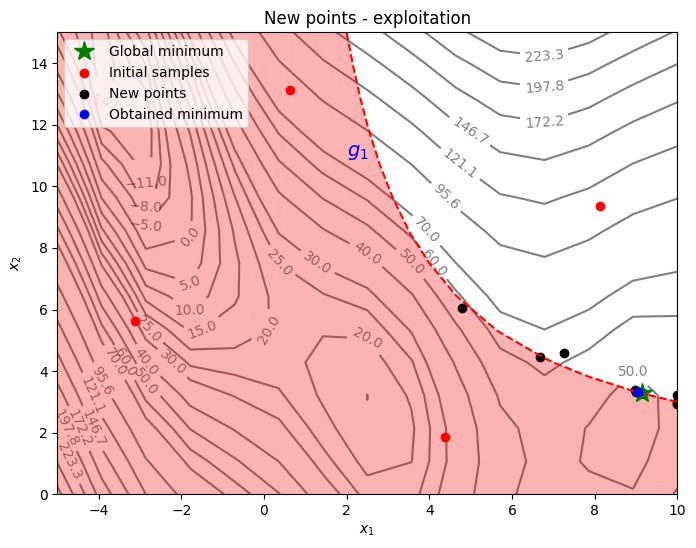

In [10]:
num_pts_per_dim = 15
x1 = np.linspace(lb[0], ub[0], num_pts_per_dim)
x2 = np.linspace(lb[1], ub[1], num_pts_per_dim)
X1, X2 = np.meshgrid(x1, x2)

x = np.hstack(( X1.reshape(-1,1), X2.reshape(-1,1) ))

Z = modified_branin(x).reshape(num_pts_per_dim, num_pts_per_dim)
G = constraint(x).reshape(num_pts_per_dim, num_pts_per_dim)

# Level
levels = np.linspace(-17, -5, 5)
levels = np.concatenate((levels, np.linspace(0, 30, 7)))
levels = np.concatenate((levels, np.linspace(40, 60, 3)))
levels = np.concatenate((levels, np.linspace(70, 300, 10)))

fig, ax = plt.subplots(figsize=(8,6))

# Contours and global opt
CS=ax.contour(X1, X2, Z, levels=levels, colors='k', linestyles='solid', alpha=0.5, zorder=-10)
ax.clabel(CS, inline=1)
ax.plot(9.143, 3.281, 'g*', markersize=15, label="Global minimum")

ax.contour(X1, X2, G, levels=[0], colors='r', linestyles='dashed')
ax.contourf(X1, X2, G, levels=np.linspace(0,G.max()), colors="red", alpha=0.3, antialiased = True)
ax.annotate('$g_1$', xy =(2.0, 11.0), fontsize=14, color='b')

# Pointss
ax.scatter(x_train[0:num_init,0], x_train[0:num_init,1], c="red", label='Initial samples')
ax.scatter(x_train[num_init:,0], x_train[num_init:,1], c="black", label='New points')
ax.plot(xbest[-1][0], xbest[-1][1], 'bo', label="Obtained minimum")

# asthetics
ax.legend(loc="upper left")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
_ = ax.set_title("New points - exploitation")

The figure above shows the history of infill points, the minimum obtained in the prescribed computational budget, and the global minimum of the problem. At the start, infill points are added at different locations since the surrogate model is changing which results in different minima. As the number of iterations increases, new infill points are added very close to the previous infill points since the surrogate minimum is more or less same. 

As can be seen in above plot, most of the points are concentrated in the feasible region along the constraint boundary. This is because the surrogate model is minimized while taking into account the constraints. However, it is possible for infeasible infill points to be added during the process, especially during the early iterations, as the surrogate models may not be accurate. Due to exploitation, there is a chance that infill points may get stuck in a local minimum. So, it is important to balance exploration and exploitatiom.